# Optimal Statistic Tutorial

In this tutorial, we will go over the basics of how to use the PTA Optimal Statistic and all of its uses! This tutorial is mostly meant as a guide such that you can copy-paste code snippets into your own projects.

This tutorial uses `Defiant` python package found here: https://github.com/GersbachKa/defiant

`Defiant` has a ton of features, some of which will not be covered here, so if you are interested in exploring more, you can check out the much more extensive example notebook
here: https://github.com/GersbachKa/defiant/blob/main/notebooks/many_examples.ipynb

Otherwise, the documentation for `Defiant` is extensive so if you have questions, the doc comments probably answer it for you! Or you can send a message if you need further assistance!

Here is an outline for this notebook:
1. [What Defiant needs from you](#what-defiant-needs-from-you)
    - The PTA data
    - The `Enterprise` PTA model
    - (optional) The `la_forge` core file or equivalent chain
2. [Creating the Defiant OS object](#creating-the-defiant-os-object)
3. [Using the optimal statistic object](#using-the-optimal-statistic-object)
    - [Traditional OS (OS)](#computing-the-os-for-the-injected-parameters---os)
    - [Noise-Marginalized OS (NMOS)](#marginalizing-over-pta-parameters---nmos)
    - [Pair Covariant OS (PCOS)](#including-pair-covariance---pcos)
    - [Per-Frequency OS (PFOS)](#spectral-estimation-with-the-os---pfos)
    - [Multi-Component OS (MCOS)](#multiple-orf-estimation---mcos)
4. [Null distributions and P-values](#null-distribution-estimation)



### Imports

In [1]:
# Magic commands for python notebooks. Not necessary, but nice to have.
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # Increases the resolution of figures shown

import numpy as np
from matplotlib import pyplot as plt

from la_forge.core import Core

import defiant 
from defiant import OptimalStatistic # The main object
from defiant import utils, orf_functions, null_distribution
from defiant import plotting as defplot # Handy plotting functions

from defiant.extra import mdc1_utils # Utilities for loading mdc1 data


libstempo not installed. PINT or libstempo are required to use par and tim files.


# [What Defiant needs from you](#optimal-statistic-tutorial)

`Defiant` needs 2-3 things that it cannot make for you:
- The PTA data in the form of a list of `enterprise` pulsar objects.
- The `Enterprise` PTA model.
- (optional) The `la_forge` core file or equivalent chain.


## The pta data

In pulsar timing, you usually get the pulsar data in one of 2 forms, either the raw timing data in the form of `.par` and `.tim` files, or as a pre-processed form like `.pkl` files containing `enterprise` pulsar objects. Its not a good idea to use pickle files off the internet unless you trust the source. However, loading pulsars from `.par` and `.tim` files requires a timing package like `PINT` or `TEMPO2`, which can cause problems with installing. As such, for this notebook, we will use the pickle file built into `Defiant`.

The built-in module `defiant.mdc1_utils` provides several utility functions, but the one we care about is `get_MDC1_psrs()` which loads the list of `enterprise` pulsar objects from the built-in pickle file along with a dictionary of the injected values.

In [2]:
# Load up the pulsars
psrs, injected_params = mdc1_utils.get_MDC1_psrs(use_pickle=True)

# This also loads the injected parameters as a dictionary
print(f'{len(psrs)=}, {injected_params=}')

# Unpack GWB parameters
gw_log10_A = injected_params['gw_log10_A']
gw_gamma = injected_params['gw_gamma']

len(psrs)=36, injected_params={'gw_log10_A': -13.301029995663981, 'gw_gamma': 4.333333333333333}


## The Enterprise PTA model

`Defiant` also requires an `Enterprise` PTA object to compute various matrix products. It is best practice to use the exact same PTA object that you used to sample with MCMC. The only  "required" modeling choices for the optimal statistic to work properly is to have a "common uncorrelated red noise" component (CURN or CRN). Every other model choice is yours to make and customize. There are caveats to using specific model choices and OS methods, but those are best saved for a 1-on-1 discussion. 

For this notebook we will make the following model choices:
1. Timing model: We will use a marginalizing timing model to marginalize over the small timing model parameters deltas. (This converts $N^{-1}$ into $D^{-1}$) 
2. White noise: Diagonal toa covariance with variance given by the measured TOA uncertainties. (This sets $N_{ij} = \delta_{ij} \sigma_i^2$) 
3. Gravitational wave background: Instead of a common correlated process, we will use a common uncorrelated red noise (CURN) component. We will use a fixed-gamma spectral index $\gamma = 13/3$. (This sets $P_{ij} = \delta_{ij} \phi_i$)
4. Intrinsic Red Noise: This behaves like CURN, but is independent per pulsar.

Somewhat arbitrarily, we will use use 10 GWB components and 10 IRN components (to match the choices made in the la_forge core used later).

In [3]:
# Create the Enterprise PTA object

from enterprise.signals import parameter, gp_signals, signal_base, white_signals
from enterprise_extensions import blocks
from enterprise_extensions.model_utils import get_tspan

gwb_gamma = 13/3
gwb_components = 10
irn_components = 10

tspan = get_tspan(psrs) # The total timespan of the PTA (max toa - min toa)

# Create the marginalizing timing model for each pulsar
tm = gp_signals.MarginalizingTimingModel(use_svd=True)

# White noise modeling is simple for MDC1. All independent toas (diagonal toa covariance)
wn = white_signals.MeasurementNoise(efac=parameter.Constant(1.0))

# Create the GWB model using a Common Red Noise (CRN) overlap reduction function
gwb = blocks.common_red_noise_block(psd='powerlaw', Tspan=tspan, 
            components=gwb_components, orf='crn', gamma_val=gwb_gamma, name='gw')

# Create the intrinsic red noise (IRN) model for each pulsar
# use the same tspan as the total PTA timespan (NANOGrav likes this)
irn = blocks.red_noise_block(psd='powerlaw', Tspan=tspan, components=irn_components)

# Create the total PTA by combining all of these together
model = tm + wn + gwb + irn

# Create the PTA by applying the model to each pulsar and combining them!
pta = signal_base.PTA([model(psr) for psr in psrs])


We can print the PTA object's summary to see all the modeling choices we made.

In [4]:
# Print the pta summary
print(pta.summary())

enterprise v3.4.4,  Python v3.12.10

Signal Name                              Signal Class                   no. Parameters      
J0030+0451_marginalizing_linear_timing_model TimingModel                    0                   

params:
__________________________________________________________________________________________
J0030+0451_measurement_noise             MeasurementNoise               0                   

params:
J0030+0451_efac:Constant=1.0                                                              
__________________________________________________________________________________________
J0030+0451_gw                            BasisGP                        1                   

Basis shape (Ntoas x N basis functions): (130, 20)
N selected toas: 130

params:
gw_log10_A:Uniform(pmin=-18, pmax=-11)                                                    
gw_gamma:Constant=4.333333333333333                                                       
________________________________

And we can also print all of the variable parameter names that we need to include in our PTA model.

In [5]:
# Print the pta parameters
for p in pta.param_names:
    print(p)

J0030+0451_red_noise_gamma
J0030+0451_red_noise_log10_A
J0218+4232_red_noise_gamma
J0218+4232_red_noise_log10_A
J0437-4715_red_noise_gamma
J0437-4715_red_noise_log10_A
J0613-0200_red_noise_gamma
J0613-0200_red_noise_log10_A
J0621+1002_red_noise_gamma
J0621+1002_red_noise_log10_A
J0711-6830_red_noise_gamma
J0711-6830_red_noise_log10_A
J0751+1807_red_noise_gamma
J0751+1807_red_noise_log10_A
J0900-3144_red_noise_gamma
J0900-3144_red_noise_log10_A
J1012+5307_red_noise_gamma
J1012+5307_red_noise_log10_A
J1022+1001_red_noise_gamma
J1022+1001_red_noise_log10_A
J1024-0719_red_noise_gamma
J1024-0719_red_noise_log10_A
J1045-4509_red_noise_gamma
J1045-4509_red_noise_log10_A
J1455-3330_red_noise_gamma
J1455-3330_red_noise_log10_A
J1600-3053_red_noise_gamma
J1600-3053_red_noise_log10_A
J1603-7202_red_noise_gamma
J1603-7202_red_noise_log10_A
J1640+2224_red_noise_gamma
J1640+2224_red_noise_log10_A
J1643-1224_red_noise_gamma
J1643-1224_red_noise_log10_A
J1713+0747_red_noise_gamma
J1713+0747_red_noise_

Since the PTA model includes intrinsic red noise but the data didn't have any injected, we need to include values for these parameters which are real small. 

In [6]:
# we need to choose IRN parameters which are most consistent with no IRN.
for p in psrs:
    # Set the IRN amplitude to the lower bound of its prior
    injected_params.update( {f'{p.name}_red_noise_log10_A': -19.9, # Close to prior boundary 
                             f'{p.name}_red_noise_gamma': 0.1} ) # Close to prior boundary
    
injected_params

{'gw_log10_A': -13.301029995663981,
 'gw_gamma': 4.333333333333333,
 'J0030+0451_red_noise_log10_A': -19.9,
 'J0030+0451_red_noise_gamma': 0.1,
 'J0218+4232_red_noise_log10_A': -19.9,
 'J0218+4232_red_noise_gamma': 0.1,
 'J0437-4715_red_noise_log10_A': -19.9,
 'J0437-4715_red_noise_gamma': 0.1,
 'J0613-0200_red_noise_log10_A': -19.9,
 'J0613-0200_red_noise_gamma': 0.1,
 'J0621+1002_red_noise_log10_A': -19.9,
 'J0621+1002_red_noise_gamma': 0.1,
 'J0711-6830_red_noise_log10_A': -19.9,
 'J0711-6830_red_noise_gamma': 0.1,
 'J0751+1807_red_noise_log10_A': -19.9,
 'J0751+1807_red_noise_gamma': 0.1,
 'J0900-3144_red_noise_log10_A': -19.9,
 'J0900-3144_red_noise_gamma': 0.1,
 'J1012+5307_red_noise_log10_A': -19.9,
 'J1012+5307_red_noise_gamma': 0.1,
 'J1022+1001_red_noise_log10_A': -19.9,
 'J1022+1001_red_noise_gamma': 0.1,
 'J1024-0719_red_noise_log10_A': -19.9,
 'J1024-0719_red_noise_gamma': 0.1,
 'J1045-4509_red_noise_log10_A': -19.9,
 'J1045-4509_red_noise_gamma': 0.1,
 'J1455-3330_red_noi

As for the samples chain, we will use the `la_forge` core that I included with in the repository. This will allow us to marginalize over the different PTA parameters

In [7]:
# While we could sample the posterior, I included a la_forge core with the samples
lfcore = Core(corepath='MDC1_FG_CURN.core')

# [Creating the Defiant OS object](#optimal-statistic-tutorial)

Next, we need to give these things to the Defiant OS object. Once we've done that, we can start computing!

In [8]:
# Now we need to create our optimal statistic object
os_obj = OptimalStatistic(psrs, pta, gwb_name='gw', core=lfcore)

# [Using the optimal statistic object](#optimal-statistic-tutorial)

Now we run the OS. The first choice you will need to make is the choice of OS, either broadband (traditional) OS or the Per-Frequency OS (PFOS). The former makes the assumption that the GWB is characterized as a power-law with some fixed spectral index, while the latter agnosticizes this by treating each frequency bin independently.

First, lets use the traditional OS.

## [Computing the OS for the injected parameters - OS](#optimal-statistic-tutorial)

For this test, we will use the injected parameters to compute the optimal statistic.
### A note about compute_OS() usage

The method ```compute_OS()``` is one of two workhorse functions with many possible use cases and two possible return formats. These use cases and returns can be found in detail in the doc-comments which can be accessed through a notebook command below. 

The gist is that users have the ability to choose how they execute the OS. These options are: 
- Supply a specific parameter vector (or vectors) by supplying ```params``` with a dictionary (or list of dictionaries) to execute the OS with.
- Supply a specific parameter vector index (or list of indexes) by supplying ```params``` with an integer (or list of integers) to execute the OS with. 
- Use the maxmimum likelihood parameter vector found within the ```.lfcore``` object by setting ```params=None``` and ```N=1```
- Use a random set of N parameter vectors (noise-marginalization) by setting ```params=None``` and setting ```N``` larger than 1.

The usage of ```the compute_PFOS()``` function has the same behavior with these parameters.

Of special note are the returns which both return a dictionary, ```output``` which contains:
- ```A2/Sk```: 
    - (OS) The best fit amplitude squared (shape=$[N, N_{\rm ORFs}]$) 
    - (PFOS) The best fit $S(f_k) = PSD*\Delta f$ (shape=$[N, N_{\rm freqs},N_{\rm ORFs}]$)
- ```A2s/Sks```: 
    - (OS) The square root variance on ```A2``` (shape=$[N, N_{\rm ORFs}, N_{\rm ORFs}]$)
    - (PFOS) The square root variance on ```Sk``` (shape=$[N, N_{\rm freqs}, N_{\rm ORFs}, N_{\rm ORFs}]$)
    - (Note: If the $N_{\rm ORFs}>1$ then these represent the covariance on the vector of ```A2```/```Sk```)
- ```idx```: The indexes of the parameters used (-1 if unknown)

If ```return_pair_vals``` is True, ```output``` also includes:
- ```xi```: The vector of pulsar pair separations $[N_{\rm pairs}]$
- ```rho/rhok```:
    - (OS) The vector of pulsar pair correlated amplitudes (shape=$[N, N_{\rm pairs}]$)
    - (PFOS) The vector of pulsar pair correlated PSDs per frequency (shape=$[N, N_{\rm freq}, N_{\rm pairs}]$)
- ```sig/sigk```: The square root variance on ```rho/rhok```
- ```C/Ck```: 
    - (OS) The pulsar pair covaraince matrix on ```rho``` (shape=$[N, N_{\rm pairs}, N_{\rm pairs}]$)
    - (PFOS) The pulsar pair covariance matrix on ```rhok``` (shape=$[N, N_{\rm freq}, N_{\rm pairs}, N_{\rm pairs}]$)

These extra pair-wise values (especially the pair covariance matrix) can be very memory hungry. Turning it off can save you lots of memory if you don't need them!

In [9]:
help(os_obj.compute_OS)

Help on method compute_OS in module defiant.core:

compute_OS(params=None, N=1, gamma=None, pair_covariance=False, return_pair_vals=True, fisher_diag=False, use_tqdm=True) method of defiant.core.OptimalStatistic instance
    Compute the OS and its various modifications.

    This is one of 2 main methods of the `OptimalStatistic` class. This method
    can compute any flavor of the OS which uses broadband estimation (i.e. constructs
    a single estimator for the whole spectrum). There are many forms in which you can
    use this method, and checking the decision tree is best for determining exactly
    what you might want and what parameters to set to accomplish that.
    NOTE: Since this method's outputs can vary widely, it will return in a dictionary
    with the keys being the output names.

    The basic usage of this method can be boiled down to the following:
    If you want to compute a single iteration of the OS:
        - supply a dictionary/array of `params`. By default, if 

Now we can proceed!

OS SNR for fixed gamma pta: 13.149888622676091


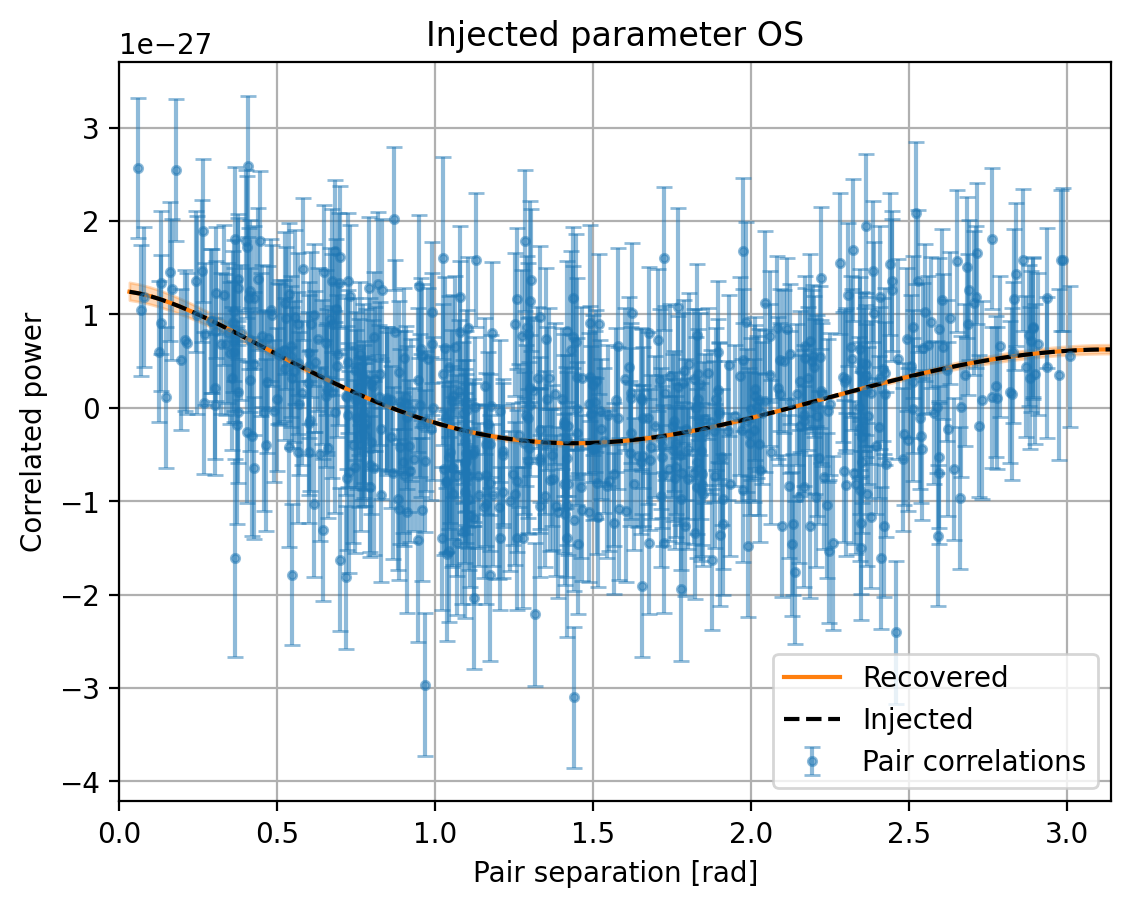

In [10]:
# By default, Defiant will use HD correlations, but you can specify!
os_obj.set_orf('hd')


# Now compute!
out = os_obj.compute_OS(injected_params)
# Unpack the output dictionary
xi, rho, sig, A2, A2s = out['xi'], out['rho'], out['sig'], out['A2'], out['A2s']


# The signal to noise is just the ratio of the estimator and std (for a non MCOS analysis)
print(f'OS SNR for fixed gamma pta: {A2/A2s}')

# Next, lets define the HD curve used for plotting
xi_range = np.linspace(0, np.pi, 100)[1:100] # Exclude xi=0
xi_hd = orf_functions.orf_hd(xi_range)

# Plot the recovered correlations
plt.errorbar(xi,rho,sig,fmt='.', capsize=3, alpha=0.5, label='Pair correlations')

# Plot the mean and 1-sigma uncertainty region
plt.plot(xi_range, 10**(2*gw_log10_A)*xi_hd, 'C1', label='Recovered')
plt.fill_between(xi_range, (A2- A2s)*xi_hd, (A2 + A2s)*xi_hd, color='C1', alpha=0.3)

# Plot the injected correlations
plt.plot(xi_range, 10**(2*gw_log10_A)*xi_hd, '--k', label='Injected')

plt.title('Injected parameter OS')
plt.xlabel('Pair separation [rad]')
plt.ylabel('Correlated power')
plt.legend()
plt.grid()
plt.xlim(0, np.pi)
plt.show()

Plotting all of the correlated pairs can be REALLY messy, so lets bin the pair correlations together!

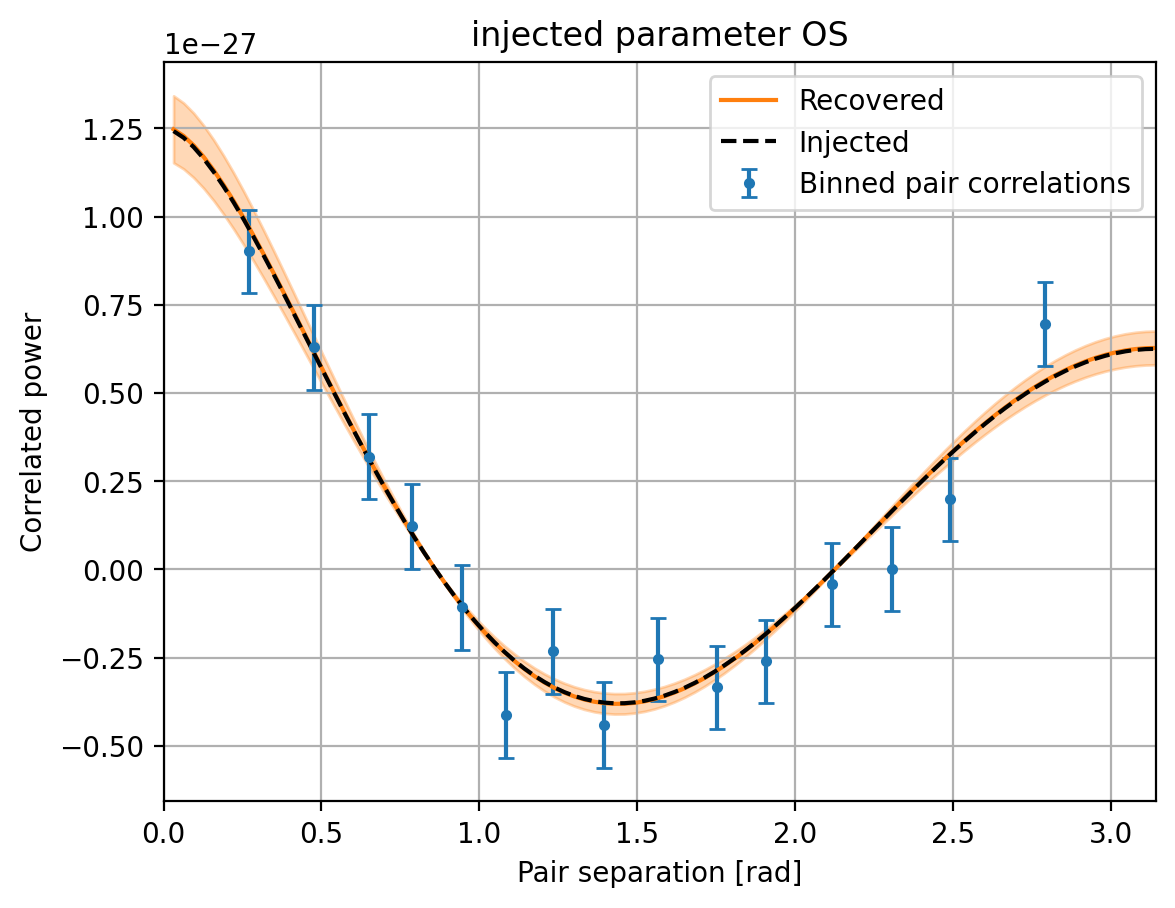

In [11]:
# Bin the pair correlations for better visualization
xi_avg, rho_avg, sig_avg = utils.binned_pair_correlations(xi, rho, sig, bins=15)

# Plot the recovered correlations
plt.errorbar(xi_avg, rho_avg, sig_avg, fmt='.', capsize=3, label='Binned pair correlations')

# Plot the mean and 1-sigma uncertainty region
plt.plot(xi_range, A2*xi_hd, 'C1', label='Recovered')
plt.fill_between(xi_range, (A2 - A2s)*xi_hd, (A2 + A2s)*xi_hd, color='C1', alpha=0.3)

# Plot the injected correlations
plt.plot(xi_range, 10**(2*gw_log10_A)*xi_hd, '--k', label='Injected')

plt.title('injected parameter OS')
plt.xlabel('Pair separation [rad]')
plt.ylabel('Correlated power')
plt.legend()
plt.grid()
plt.xlim(0, np.pi)
plt.show()

## [Marginalizing over PTA parameters - NMOS](#optimal-statistic-tutorial)

Choosing a single parameter vector from the posterior distribution leads to biased estimates to the true underlying parameters. To mitigate this, we marginalize over the noise parameters, effectively averaging over their posterior distribution.

This approach is known as the Noise Marginalized Optimal Statistic (NMOS), and it provides a more robust estimate of the correlated signal by accounting for the uncertainty in the noise parameters. This is done (rather bluntly) as just running the OS over many draws from the posterior distribution. This makes distributions of amplitude estimators and uncertainties. Note that if you want the total distribution of amplitudes, you need to combine both of these distributions through `Uncertainty Sampling`

We can then get the distribution of SNRs through the same equation!

NMOS Iters: 100%|██████████| 1000/1000 [00:03<00:00, 284.11it/s]


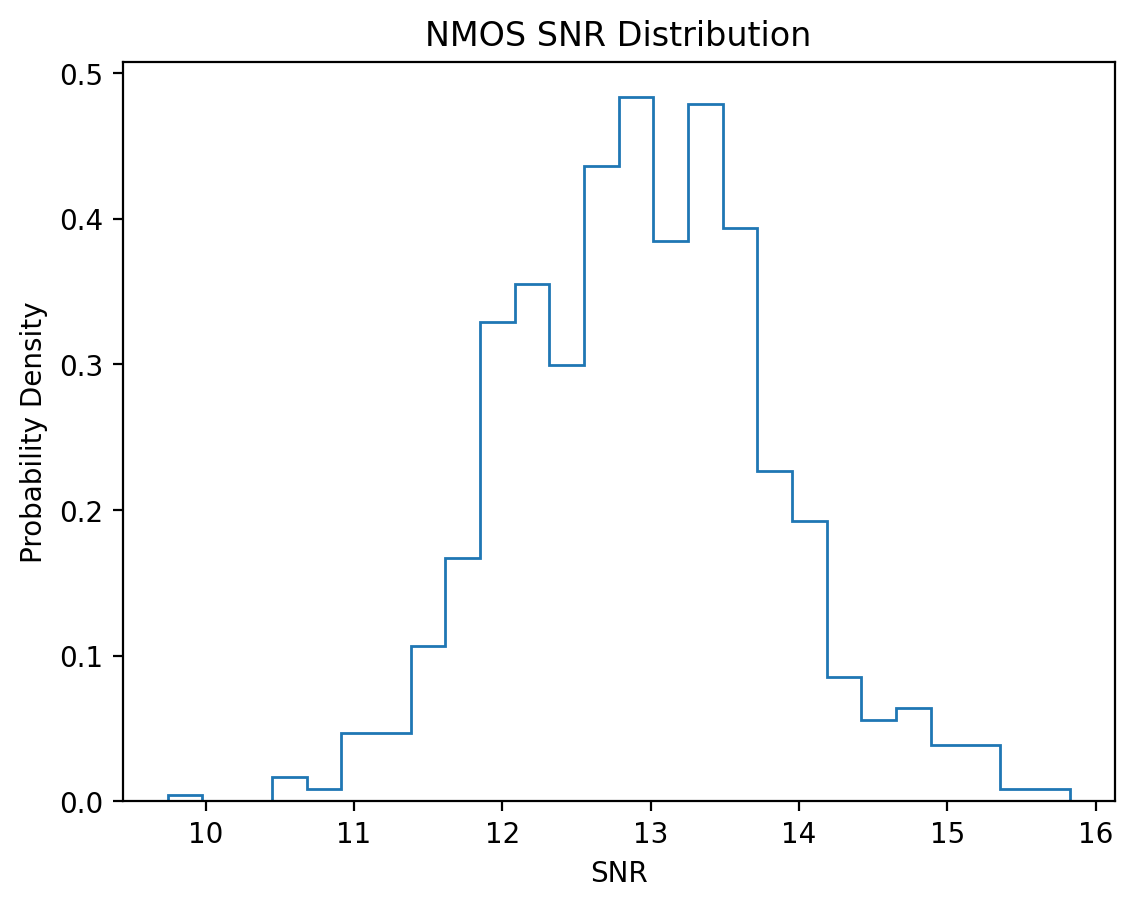

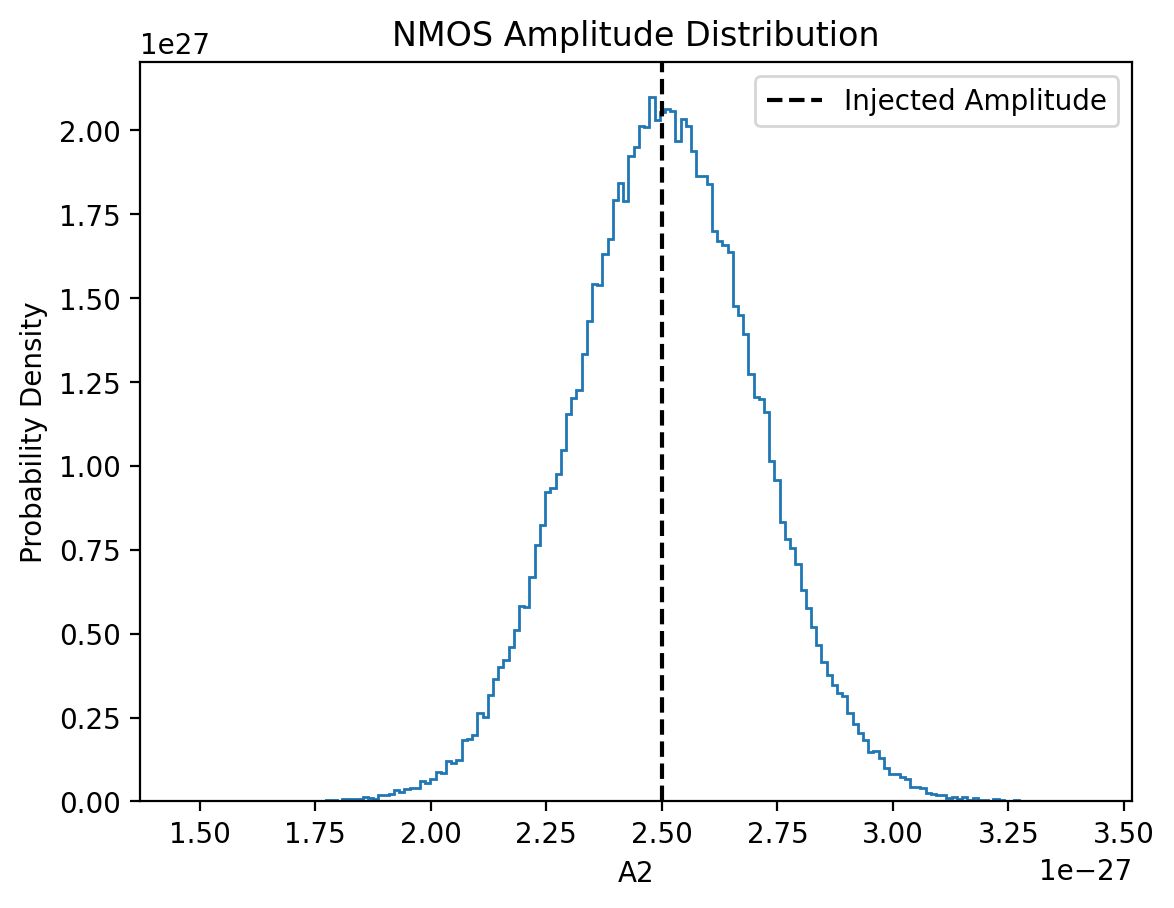

In [12]:
# While we could sample the posterior, I included a la_forge core with the samples
lfcore = Core(corepath='MDC1_FG_CURN.core')

# Add the la_forge core to the object
os_obj.set_chain_params(lfcore)

# Since we don't need pair correlations for every iteration (memory expensive), just
# store the estimator and uncertainty while tossing out the pair quantities.
# If you set a core, when params is None (default) and N>1, it will grab N random
# samples from the core to compute the OS
out = os_obj.compute_OS(N=1_000, return_pair_vals=False)
A2, A2s = out['A2'], out['A2s']

# plot the SNR distribution of the NMOS
plt.hist( A2/A2s, bins='auto', histtype='step', density=True)

plt.title('NMOS SNR Distribution')
plt.xlabel('SNR')
plt.ylabel('Probability Density')
plt.show()


# Plot the distribution of amplitude estimators
tot_A2 = utils.uncertainty_sample(A2, A2s, pfos=False, mcos=False)
plt.hist(tot_A2, bins='auto', histtype='step', density=True)
# Plot the injected amplitude
plt.axvline(10**(2*gw_log10_A), color='k', linestyle='--', label='Injected Amplitude')
plt.title('NMOS Amplitude Distribution')
plt.xlabel('A2')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

## [Including pair covariance - PCOS](#optimal-statistic-tutorial)

As was mentioned before, the OS as a parameter estimator is biased in medium to high signal regimes. While the significance estimator remains useful, the amplitude estimator fails quite spectacularly. To combat this, we can include higher order approximations into our maximum likelihood estimation. The next order that we need to include is done through the pair covariant OS (PCOS). The PCOS changes the estimator to being pair-independent to being pair covariant. To do so, we can simply replace the original estimator equation:
$$ \hat{A}^2_{\rm gw} = \frac{ \sum_{a<b} \rho_{ab} \Gamma_{ab} / \sigma^2_{ab}  }{ \sum_{a<b} \Gamma^2_{ab} / \sigma^2_{ab} } $$

into a matrix version:
$$ \hat{A}^2_{\rm gw} = (\vec{\Gamma}^T C^{-1} \vec{\Gamma})^{-1} \vec{\Gamma}^T C^{-1} \vec{\rho} $$

where $ C = \langle \vec{\rho} \vec{\rho}^T \rangle $ is the pulsar pair covariance matrix.

The downside to this method is the calculation of C is a bit crazy considering the size of this matrix is $(N_{\rm pairs} \times N_{\rm pairs})$, where $N_{\rm pairs} = \frac{N_{\rm psrs} (N_{\rm psrs}-1)}{2}$ is the number of pulsar pairs. The number of elements scales with the $N_{\rm psrs}^4$. That equates to nearly 25 million elements if you have 100 pulsars. The upside, is that I spent an enormous amount of time to optimize this to make this feasible even for 100 pulsars! On my M1 Macbook, I can calculate 700,000 elements per second, but more modern hardware can do much better.

As an additional note, enabling pair covariance, especially when combined with noise marginalization can be very memory intensive. If you are saving all of the pair covariance matrices, the memory requirements are $N_{\rm iter} \times N_{\rm pairs}^2$, where $N_{\rm iter}$ is the number of nmos iterations. This can quickly become prohibitive for large numbers of pulsars or iterations. For the same 100 pulsar dataset, the memory requiresments are approximately 200 MB per iteration.

Turning pair covariance on is as simple as setting `pair_covariance=True`. There is a minor change to the bin averaging procedure where it now needs the ORF function along with the pair covariance matrix. 


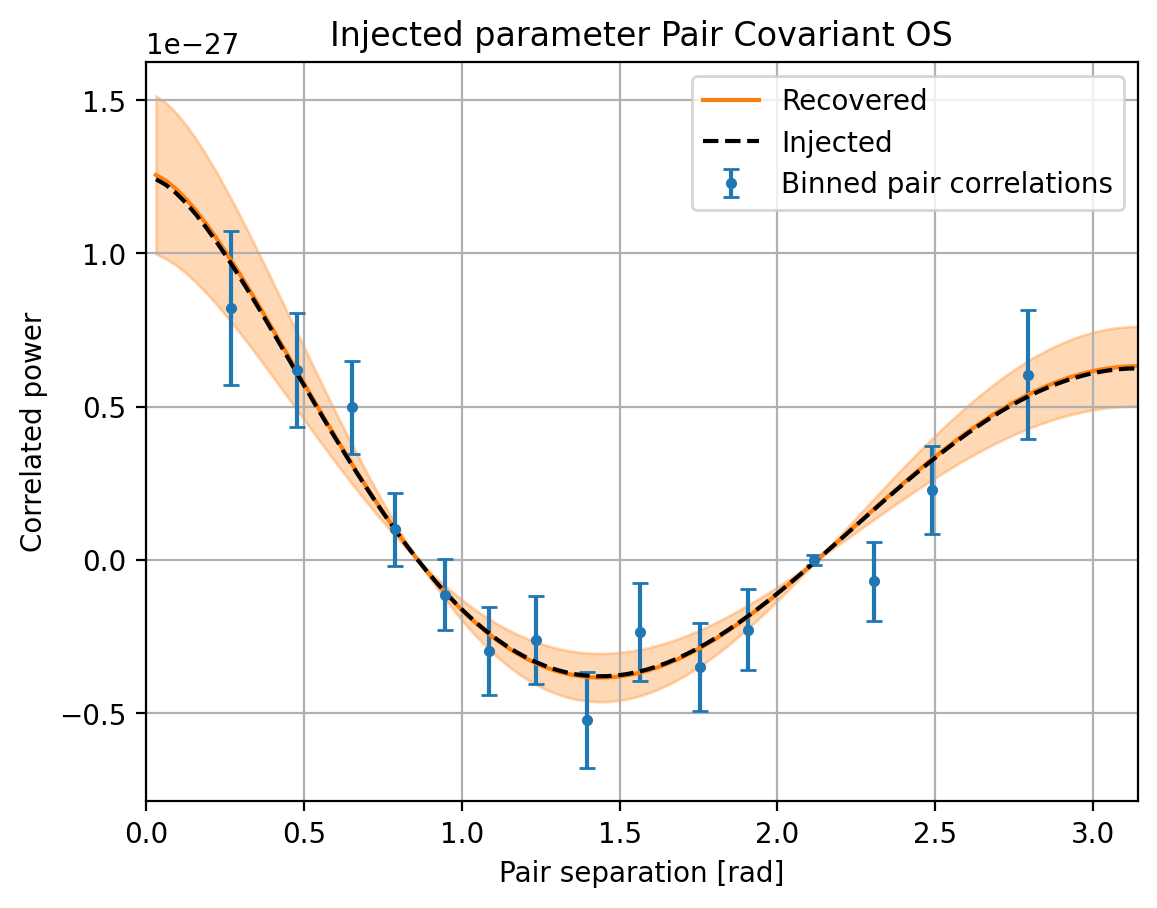

In [13]:
# Lets go back to using the injected. Pair covariance is computationally expensive
out = os_obj.compute_OS(injected_params, pair_covariance=True)
xi, rho, C, A2, A2s = out['xi'], out['rho'], out['C'], out['A2'], out['A2s']

xi_avg, rho_avg, sig_avg = utils.binned_pair_correlations(xi, rho, C, bins=15, orf='hd')

# Plot the recovered correlations
plt.errorbar(xi_avg, rho_avg, sig_avg, fmt='.', capsize=3, label='Binned pair correlations')

# Plot the mean and 1-sigma uncertainty region
plt.plot(xi_range, A2*xi_hd, 'C1', label='Recovered')
plt.fill_between(xi_range, (A2- A2s)*xi_hd, (A2 + A2s)*xi_hd, color='C1', alpha=0.3)

# Plot the injected correlations
plt.plot(xi_range, 10**(2*gw_log10_A)*xi_hd, '--k', label='Injected')

plt.title('Injected parameter Pair Covariant OS')
plt.xlabel('Pair separation [rad]')
plt.ylabel('Correlated power')
plt.legend()
plt.grid()
plt.xlim(0, np.pi)
plt.show()

## [Spectral estimation with the OS - PFOS](#optimal-statistic-tutorial)

Next, we can relax the assumption of a powerlaw spectral shape by estimation the correlation pattern per-frequency. This is done through a frequency-independent fitting technique where we calculate the pair correlations per frequency and then fit the correlation pattern. 

`Defiant` provides a very similar function called `compute_PFOS` for per-frequency optimal statistic estimation. This function has slightly different dictionary keys compared to `compute_OS`. Instead the individual pair estimates like `rho`, it has `rhok` which are the per-frequency variations with shape $(N_{\rm freqs}, N_{\rm pairs})$. Since we do care about the estimation, we do need to use pair covariance as well.

Here is the help command!


In [14]:
help(os_obj.compute_PFOS)

Help on method compute_PFOS in module defiant.core:

compute_PFOS(params=None, N=1, pair_covariance=False, narrowband=False, return_pair_vals=True, fisher_diag=False, select_freq=None, use_tqdm=True) method of defiant.core.OptimalStatistic instance
    Compute the PFOS and its various modifications.

    This is one of 2 main methods of the `OptimalStatistic` class. This method
    can computes the different flavors of the PFOS (i.e. a free-spectrum search).
    There are many forms in which you can use this method, and checking the
    decision tree is best for determining exactly what you might want and what
    parameters to set to accomplish that.
    NOTE: Since this method's outputs can vary widely, it will return in a dictionary
    with the keys being the output names.

    The basic usage of this method can be boiled down to the following:
    If you want to compute a single iteration of the PFOS:
        - supply a dictionary of `params`. By default, if `params=None` and `N=1

PFOS Freqs: 100%|██████████| 10/10 [00:03<00:00,  2.76it/s]


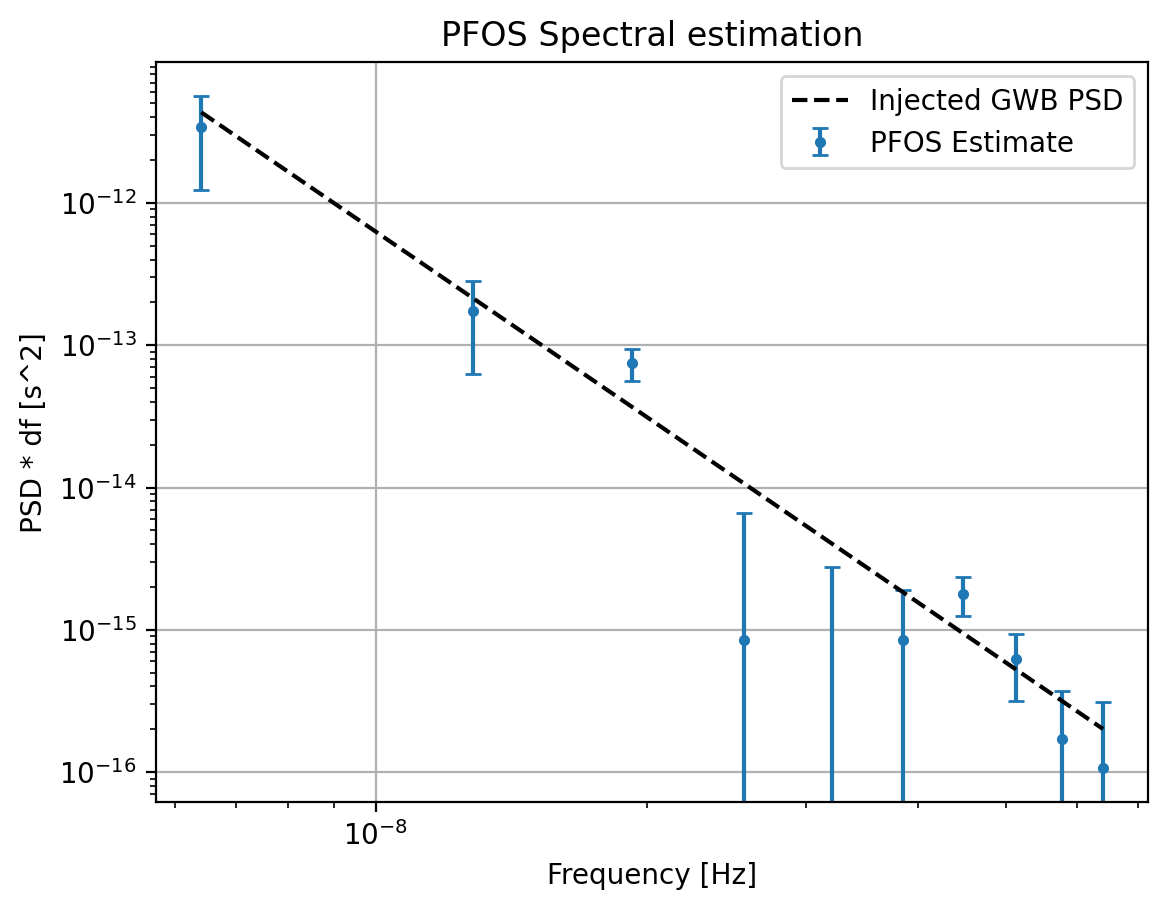

In [15]:
# PC should be true for parameter estimation
out = os_obj.compute_PFOS(injected_params, pair_covariance=True) 
xi, rhok, Ck, Sk, Sks = out['xi'], out['rhok'], out['Ck'], out['Sk'], out['Sks']


plt.errorbar(os_obj.freqs, Sk, Sks, fmt='.', capsize=3, label='PFOS Estimate')

gw_psd = utils.powerlaw(os_obj.freqs, gw_log10_A, gw_gamma)
plt.plot(os_obj.freqs, gw_psd, '--k', label='Injected GWB PSD')

plt.title('PFOS Spectral estimation')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD * df [s^2]')
plt.grid()
plt.legend()
plt.loglog()
plt.show()

Note that F5 spectral estimator is negative! That may seem weird (how do you get negative power?), but this is a consequence of the analytic chi-square minimization technique we use. In order to use analytic solutions, we CANNOT restrict the space of allowed powers. But what does negative power mean in this case? Well, its just inverting the HD curve! This isn't physical, just a best fit to noise. If you see negative power, and its not significant (i.e. ~SNR<2), you don't need to worry much. However, if its significant, it may indicate an issue with the data or the model!

In addition to the spectral estimation, we can also plot the pair correlations per frequency. For this case, we will just plot F5, but there is nothing stopping you from plotting the other frequencies.

 

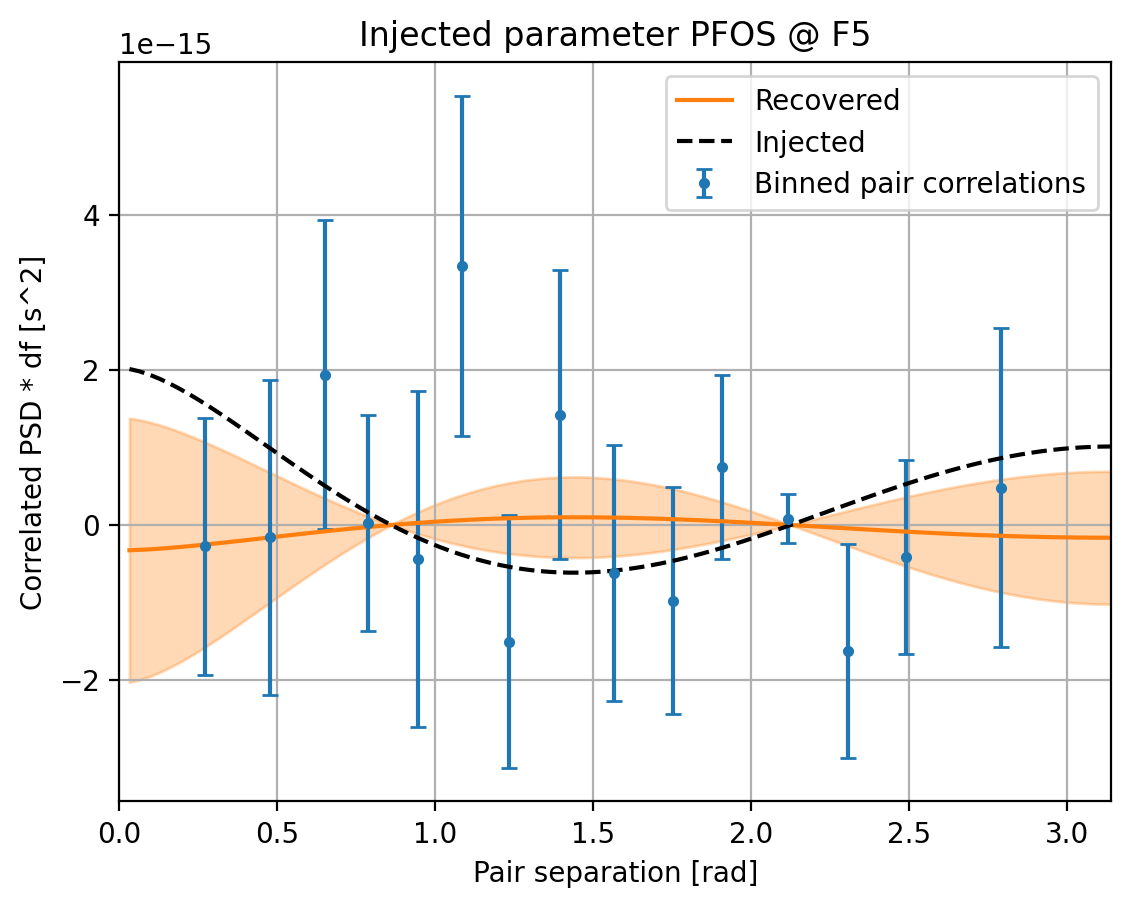

In [16]:
# Get the correlation of the second frequency bin
NF = 5
xi_avg, rho_avg, sig_avg = utils.binned_pair_correlations(xi, rhok[NF-1], Ck[NF-1], 
                                                          bins=15, orf='hd')

# Plot the recovered correlations
plt.errorbar(xi_avg, rho_avg, sig_avg, fmt='.', capsize=3, 
             label='Binned pair correlations')

# Plot the mean and 1-sigma uncertainty region
plt.plot(xi_range, Sk[NF-1]*xi_hd, 'C1', label='Recovered')
plt.fill_between(xi_range, (Sk[NF-1]- Sks[NF-1])*xi_hd, 
                 (Sk[NF-1] + Sks[NF-1])*xi_hd, color='C1', alpha=0.3)

# Plot the injected correlations
plt.plot(xi_range, gw_psd[NF-1]*xi_hd, '--k', label='Injected')

plt.title(f'Injected parameter PFOS @ F{NF}')
plt.xlabel('Pair separation [rad]')
plt.ylabel('Correlated PSD * df [s^2]')
plt.legend()
plt.grid()
plt.xlim(0, np.pi)
plt.show()

## [Multiple ORF estimation - MCOS](#optimal-statistic-tutorial)

Another extension that is useful from the OS is the Multi-Component OS (MCOS). This extension allows the simultaneous estimation of multiple components, or ORFs, within the data. This can be particularly helpful when searching for correlated noise processes such as dipolar correlations (which can be caused by a mismodeled ephemeris), or monopolar correlations (which can be caused by clock errors).

Setting up the MCOS is as simple as defining the list of ORF functions to use.
Note that the outputs `A2` and `A2s` have changed a bit when using the MCOS, as they now correspond to the multiple components being estimated simultaneously. As such, `A2` is the amplitude estimator vector of shape $(N_{\rm orfs})$ and `A2s` is the COVARIANCE matrix of shape $(N_{\rm orfs}, N_{\rm orfs})$. The covariance is important as before we returned the standard deviation (square root variance), but now we need the full covariance matrix to properly account for the correlations between the different components.

You can approximate the standard deviation of each component by taking the square root of the diagonal elements of the covariance matrix `A2s`. This can give you the individual ORF SNRs for each component, or you can calculate the total SNR through
$\text{SNR}_{\rm total} = \sqrt{ \hat{\theta}^T \Sigma^{-1} \hat{\theta} }$ where 
$\hat{\theta}$ is the vector of amplitude estimators `A2` and $\Sigma$ is the covariance matrix `A2s`.

SNR per ORF [hd, dp, mp]: [12.85155042  0.17480599 -0.77339844]
Total SNR: 13.1729140245763


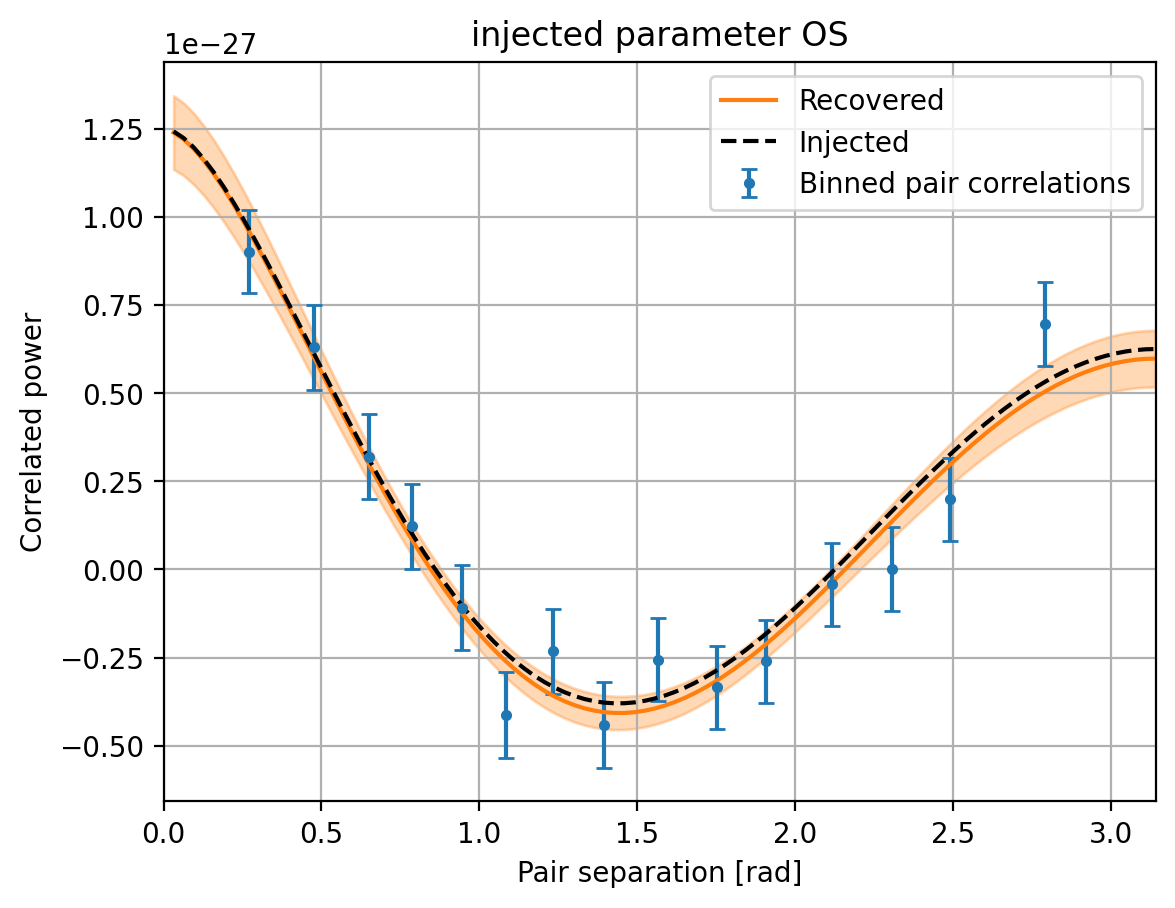

In [17]:
os_obj.set_orf(['hd', 'dipole', 'monopole'])

out = os_obj.compute_OS(injected_params)
xi, rho, sig, A2, A2s = out['xi'], out['rho'], out['sig'], out['A2'], out['A2s']

# Compute the binned pair correlations
xi_avg, rho_avg, sig_avg = utils.binned_pair_correlations(xi, rho, sig, bins=15)

# Print the signal to noise ratios for each ORF
print(f'SNR per ORF [hd, dp, mp]: {A2/np.sqrt(np.diag(A2s))}')
# Print the total signal to noise ratio
tot_snr = np.sqrt( A2[None,:] @ np.linalg.solve(A2s, A2[:,None]) ).item()
print(f'Total SNR: {tot_snr}')


# Plot the recovered correlations
plt.errorbar(xi_avg, rho_avg, sig_avg, fmt='.', capsize=3, 
             label='Binned pair correlations')

# Plot the mean and 1-sigma uncertainty region
# We need to do a slighlty different process for MCOS, so lets use the utils function
mean, sigma = utils.calculate_mean_sigma_for_MCOS(xi_range, A2, A2s, ['hd','dp','mp'])
plt.plot(xi_range, mean, 'C1', label='Recovered')
plt.fill_between(xi_range, mean-sigma, mean+sigma, color='C1', alpha=0.3)

# Plot the injected correlations
plt.plot(xi_range, 10**(2*gw_log10_A)*xi_hd, '--k', label='Injected')

plt.title('injected parameter OS')
plt.xlabel('Pair separation [rad]')
plt.ylabel('Correlated power')
plt.legend()
plt.grid()
plt.xlim(0, np.pi)
plt.show()


Note how around the 0 crossings, the HD correlations from the previous analyses will always squeeze their uncertainties since changing the value of the amplitude doesn't change where the 0 crossings are. In this analysis with the MCOS, we are allowing some variations from 0 in these regions from the sum of HD+DP+MP. Looking at the SNR per ORF, it is mostly due to the inclusion of the monopole. However, that doesn't mean that the monopole is significant, just that it is being used to soak up the variance towards these 0 crossing nodes. 

# [Null distribution estimation](#optimal-statistic-tutorial)

Okay, so now we have some estimates for the significance in the form of an SNR, but what does this value really mean? Well, on its own, it approximates the number of sigma away the estimator is from noise. The problem is that this is only an approximation. It isn't actually the true significance because the estimator distribution itself is non-gaussian. In order to get the real significance, we need to find where our estimator lies within its own null distribution. 

The null distribution is the set of estimators for which the statistics of the data is the same, but under the null hypothesis. Since our null hypothesis is nearly the same, but without correlations (i.e. common uncorrelated red noise instead of common correlated red noise), we need to find ways to destroy correlations while keeping the rest of the data consistent. 

There are 3 main ways in which to construct the null distribution:
1. `GX2` - The GX2 is an analytic method to construct the pdf of the null distribution assuming that the timing residuals are Gaussian distributed. This method is not yet implemented in `Defiant`, but if you want to do it, feel free to pull request it!
2. `Phase Shift` - Phase shifting is a numerical method to construct the null distribution by randomly shifting the phases, swapping amplitudes between sine and cosine modes, for each frequency and constructing the SNR. This works as the correlations are constructed as $\rho_{ab} \propto \langle a_a a_b \rangle \propto \Gamma_{ab}$. Phase shifting eliminates the correlations while keeping the rest of the data consistent.
3. `Sky Scramble` - Sky scrambling is another numerical method where the positions of the pulsars on the sky are randomly scrambled, effectively destroying the expected correlation pattern while preserving the individual noise properties of each pulsar. This breaks the correlations by changing the overlap reduction function $\Gamma_{ab}$ while keeping the data the same.

I encourage you to explore the notebook here for a deeper dive into null distributions: https://github.com/GersbachKa/defiant/blob/main/notebooks/null_distributions.ipynb

You can combine 2 and 3 into a hybrid approach sometimes called super scrambling, but often phase shifting is sufficient on its own for constructing the null distribution.

s scrambles: 100%|██████████| 5000/5000 [00:18<00:00, 273.10it/s]


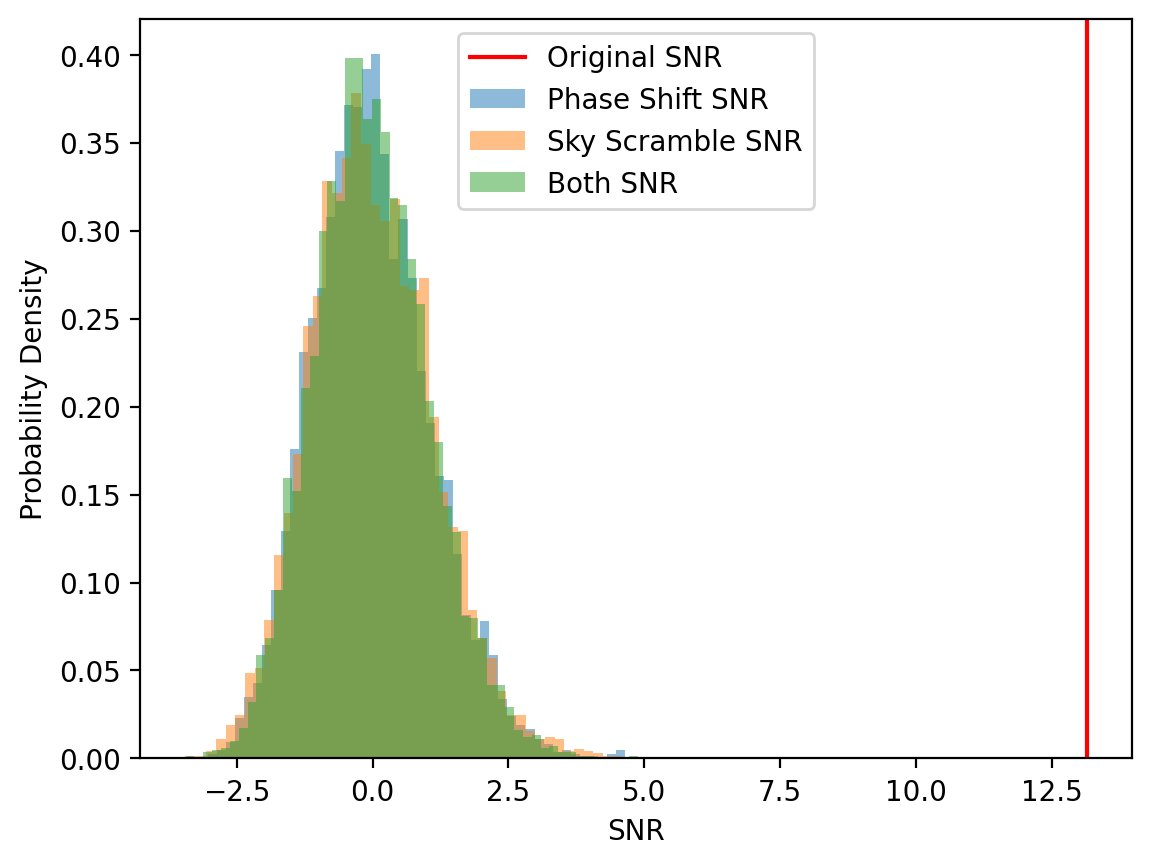

In [18]:
# Lets reset to the base OS 
os_obj.set_orf('hd')

# Compute the original SNR
out = os_obj.compute_OS(injected_params, return_pair_vals=False)
SNR = out['A2']/out['A2s'] # This is the comparison SNR

n = 5_000
# First, phase shifts
p_ps, _, pshift_SNR = null_distribution.phase_shift_OS(os_obj, injected_params, 
                                                       n_shifts=n)

# Second, sky scrambles
p_ss, _, scramble_SNR = null_distribution.sky_scramble_OS(os_obj, injected_params, 
                                                          n_scrambles=n)

# Third, both
p_both, _, both_SNR = null_distribution.super_scramble_OS(os_obj, injected_params, 
                                                          n_scrambles=n)

# Plot the results
plt.axvline(SNR, color='r', linestyle='-', label='Original SNR')

plt.hist(pshift_SNR, bins='auto', density=True, color='C0', alpha=0.5, 
         label='Phase Shift SNR')
plt.hist(scramble_SNR, bins='auto', density=True, color='C1', alpha=0.5, 
         label='Sky Scramble SNR')
plt.hist(both_SNR, bins='auto', density=True, color='C2', alpha=0.5, 
         label='Both SNR')
plt.xlabel('SNR')
plt.ylabel('Probability Density')
plt.legend()
plt.show()


Since this GWB is too loud to actually get any null distribution samples near the measured SNR, lets just say that our target SNR is actually 3. Given that, what is the p-value?

In [19]:
# This GWB is LOUD, lets just say we have an SNR 3, what is our p-value?
target_SNR = 3
# Percentage of samples below the target SNR
p_value_ps = np.sum(target_SNR < pshift_SNR)/len(pshift_SNR) 
p_value_ss = np.sum(target_SNR < scramble_SNR)/len(scramble_SNR)
p_value_both = np.sum(target_SNR < both_SNR)/len(both_SNR)

# To switch to n-sigma
from scipy.stats import norm
p_value_ps_sigma = norm.ppf(1 - p_value_ps)
p_value_ss_sigma = norm.ppf(1 - p_value_ss)
p_value_both_sigma = norm.ppf(1 - p_value_both)

print(f"P-value for phase shift: {p_value_ps}, {np.round(p_value_ps_sigma, 2)}-sigma")
print(f"P-value for sky scramble: {p_value_ss}, {np.round(p_value_ss_sigma, 2)}-sigma")
print(f"P-value for both: {p_value_both}, {np.round(p_value_both_sigma, 2)}-sigma")

P-value for phase shift: 0.0062, 2.5-sigma
P-value for sky scramble: 0.0098, 2.33-sigma
P-value for both: 0.0046, 2.6-sigma
